# Tutorial 1: the household, pushed and broken

Lecture 3's household: 60 ages, 45 of them working, $\beta = 0.96$, $R = 1.04$, $\sigma = 2$, 300 grid points. First the solver exactly as we typed it in the lecture, and two helpers: one to simulate a life, one to draw it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

p = dict(J=60, J_R=45, beta=0.96, R=1.04, sigma=2.0, w=1.0, tau=0.0, repl=0.4, a_max=25.0, n_a=300)
ages = 20 + np.arange(1, p["J"] + 1)

def efficiency_profile(J, J_R):
    j = np.arange(1, J + 1)
    e = np.exp(0.06 * j - 0.0012 * j**2)
    e = e / e[:J_R].mean()
    e[J_R:] = 0.0
    return e

def income_profile(p):
    e = efficiency_profile(p["J"], p["J_R"])
    y = (1 - p["tau"]) * p["w"] * e
    y[p["J_R"]:] = p["repl"] * p["w"] * e[:p["J_R"]].mean()
    return y

def utility(c, sigma):
    return np.log(c) if sigma == 1.0 else c ** (1 - sigma) / (1 - sigma)

def solve_household_grid(p):
    J, R, beta, sigma = p["J"], p["R"], p["beta"], p["sigma"]
    a = np.linspace(0.0, p["a_max"], p["n_a"])
    y = income_profile(p)
    V = np.zeros((J + 1, len(a)))                  # V[J] = 0 is the terminal condition
    policy = np.zeros((J, len(a)), dtype=int)
    for j in range(J - 1, -1, -1):                 # last age first
        c = R * a[:, None] + y[j] - a[None, :]     # rows: a today; columns: a' choices
        u = np.full(c.shape, -np.inf)
        u[c > 0] = utility(c[c > 0], sigma)
        value = u + beta * V[j + 1][None, :]
        policy[j] = value.argmax(axis=1)
        V[j] = value.max(axis=1)
    return dict(a_grid=a, V=V, policy=policy, y=y)

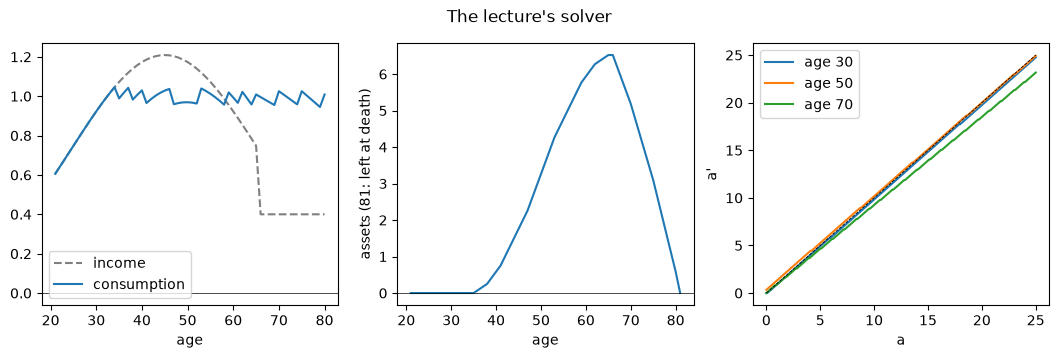

last-age policy saves nothing: True
peak assets 6.52; left at death 0.00; ages with c <= 0: 0
consumption growth, ages 41 to 60: +0.0015


In [2]:
def simulate_profile(sol, p):
    """Follow the policy from a = 0 at the first age. Returns assets (J+1) and consumption (J)."""
    a, pol, y, R = sol["a_grid"], sol["policy"], sol["y"], p["R"]
    idx = int(np.argmin(np.abs(a)))                # the grid point closest to zero
    assets, cons = [a[idx]], []
    for j in range(p["J"]):
        nxt = pol[j, idx]
        cons.append(R * a[idx] + y[j] - a[nxt])
        assets.append(a[nxt]); idx = nxt
    return np.array(assets), np.array(cons)

def show(sol, p, title):
    """The handout's three panels, and the numbers worth reading."""
    assets, cons = simulate_profile(sol, p); a = sol["a_grid"]
    fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
    ax[0].plot(ages, sol["y"], "--", color="grey", label="income"); ax[0].plot(ages, cons, label="consumption")
    ax[0].axhline(0, color="k", lw=0.5); ax[0].set_xlabel("age"); ax[0].legend()
    ax[1].plot(np.append(ages, 81), assets); ax[1].axhline(0, color="k", lw=0.5)
    ax[1].set_xlabel("age"); ax[1].set_ylabel("assets (81: left at death)")
    for j in (9, 29, 49):
        ax[2].plot(a, a[sol["policy"][j]], label=f"age {21 + j}")
    ax[2].plot(a, a, "k--", lw=0.6); ax[2].set_xlabel("a"); ax[2].set_ylabel("a'"); ax[2].legend()
    fig.suptitle(title); plt.show()
    print(f"last-age policy saves nothing: {bool(np.all(a[sol['policy'][-1]] == 0))}")
    print(f"peak assets {assets.max():.2f}; left at death {assets[-1]:.2f}; ages with c <= 0: {int((cons <= 0).sum())}")
    print(f"consumption growth, ages 41 to 60: {np.diff(np.log(np.abs(cons[20:40]))).mean():+.4f}")

show(solve_household_grid(p), p, "The lecture's solver")

## Exercise 1: the grid

What happens with 30 points? Compare the spacing with a year's income.

n_a =   30: spacing 0.862, peak assets 0.00
n_a =  100: spacing 0.253, peak assets 6.06
n_a =  300: spacing 0.084, peak assets 6.52


n_a = 1000: spacing 0.025, peak assets 6.48


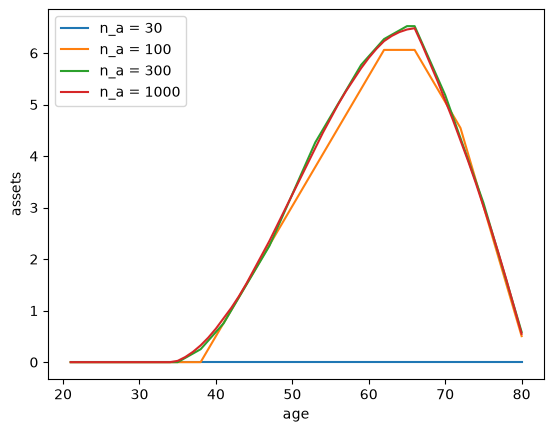

In [3]:
for n in (30, 100, 300, 1000):
    q = {**p, "n_a": n}
    sol = solve_household_grid(q)
    assets, cons = simulate_profile(sol, q)
    plt.plot(ages, assets[:-1], label=f"n_a = {n}")
    print(f"n_a = {n:4d}: spacing {sol['a_grid'][1] - sol['a_grid'][0]:.3f}, peak assets {assets.max():.2f}")
plt.legend(); plt.xlabel("age"); plt.ylabel("assets"); plt.show()

## Exercise 2: patience and smoothing

The Euler equation $c_j^{-\sigma} = \beta R\, c_{j+1}^{-\sigma}$ says $c_{j+1}/c_j = (\beta R)^{1/\sigma}$. Which household breaks the prediction, and why?

In [4]:
for beta in (0.90, 0.96, 0.99):
    for sigma in (1.0, 5.0):
        q = {**p, "beta": beta, "sigma": sigma}
        sol = solve_household_grid(q)
        assets, cons = simulate_profile(sol, q)
        slope = np.diff(np.log(cons[20:40])).mean()
        print(f"beta {beta}, sigma {sigma:.0f}: slope {slope:+.4f}, Euler says {(beta * q['R']) ** (1 / sigma) - 1:+.4f}, "
              f"peak assets {assets.max():5.2f}, consumption at 25 {cons[4]:.3f} vs income {sol['y'][4]:.3f}")

beta 0.9, sigma 1: slope -0.0182, Euler says -0.0640, peak assets  0.59, consumption at 25 0.748 vs income 0.748
beta 0.9, sigma 5: slope -0.0157, Euler says -0.0131, peak assets  3.76, consumption at 25 0.748 vs income 0.748
beta 0.96, sigma 1: slope -0.0034, Euler says -0.0016, peak assets  6.27, consumption at 25 0.748 vs income 0.748
beta 0.96, sigma 5: slope +0.0015, Euler says -0.0003, peak assets  6.61, consumption at 25 0.748 vs income 0.748
beta 0.99, sigma 1: slope +0.0280, Euler says +0.0296, peak assets 19.48, consumption at 25 0.527 vs income 0.748
beta 0.99, sigma 5: slope +0.0075, Euler says +0.0059, peak assets  8.19, consumption at 25 0.748 vs income 0.748


## Exercise 3: four broken solvers

Each cell is the lecture's solver with exactly one line changed, marked `# CHANGED`. Try changing it back, or breaking a different line.

### Version A

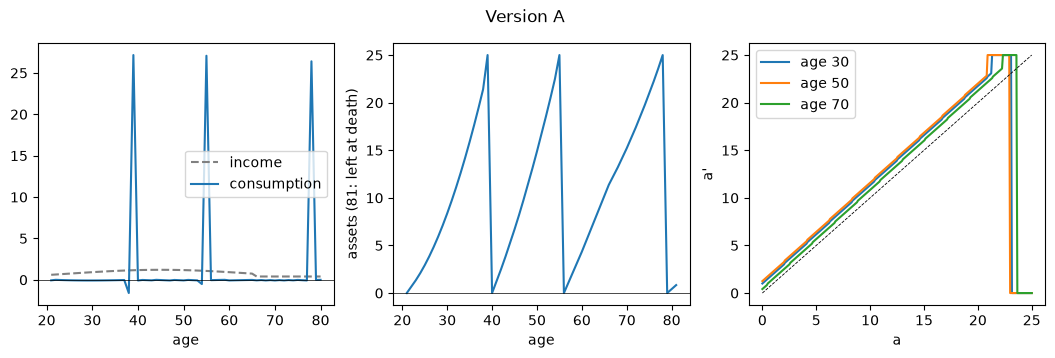

last-age policy saves nothing: False
peak assets 25.00; left at death 0.84; ages with c <= 0: 57
consumption growth, ages 41 to 60: +0.0744


In [5]:
def solve_A(p):
    J, R, beta, sigma = p["J"], p["R"], p["beta"], p["sigma"]
    a = np.linspace(0.0, p["a_max"], p["n_a"])
    y = income_profile(p)
    V = np.zeros((J + 1, len(a)))
    policy = np.zeros((J, len(a)), dtype=int)
    for j in range(J - 1, -1, -1):
        c = R * a[:, None] + y[j] - a[None, :]
        u = np.full(c.shape, 0.0)                  # CHANGED: was np.full(c.shape, -np.inf)
        u[c > 0] = utility(c[c > 0], sigma)
        value = u + beta * V[j + 1][None, :]
        policy[j] = value.argmax(axis=1)
        V[j] = value.max(axis=1)
    return dict(a_grid=a, V=V, policy=policy, y=y)

show(solve_A(p), p, "Version A")

### Version B

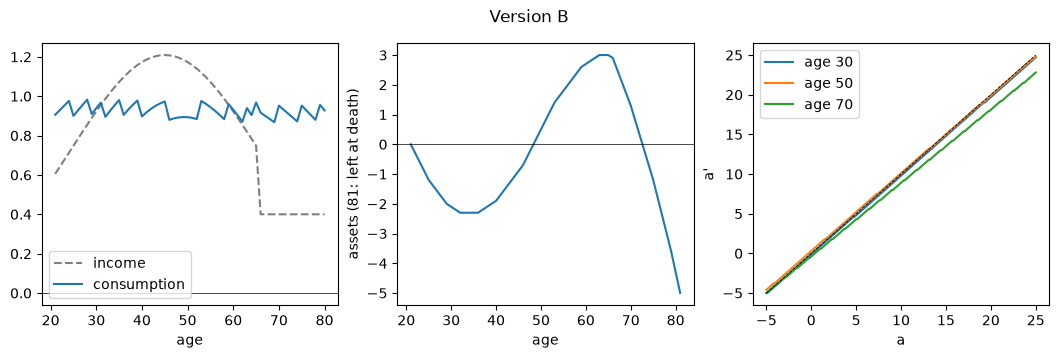

last-age policy saves nothing: False
peak assets 3.00; left at death -5.00; ages with c <= 0: 0
consumption growth, ages 41 to 60: +0.0007


In [6]:
def solve_B(p):
    J, R, beta, sigma = p["J"], p["R"], p["beta"], p["sigma"]
    a = np.linspace(-5.0, p["a_max"], p["n_a"] + 1)  # CHANGED: was np.linspace(0.0, p["a_max"], p["n_a"]); +1 puts 0 on the grid
    y = income_profile(p)
    V = np.zeros((J + 1, len(a)))
    policy = np.zeros((J, len(a)), dtype=int)
    for j in range(J - 1, -1, -1):
        c = R * a[:, None] + y[j] - a[None, :]
        u = np.full(c.shape, -np.inf)
        u[c > 0] = utility(c[c > 0], sigma)
        value = u + beta * V[j + 1][None, :]
        policy[j] = value.argmax(axis=1)
        V[j] = value.max(axis=1)
    return dict(a_grid=a, V=V, policy=policy, y=y)

show(solve_B(p), p, "Version B")

### Version C

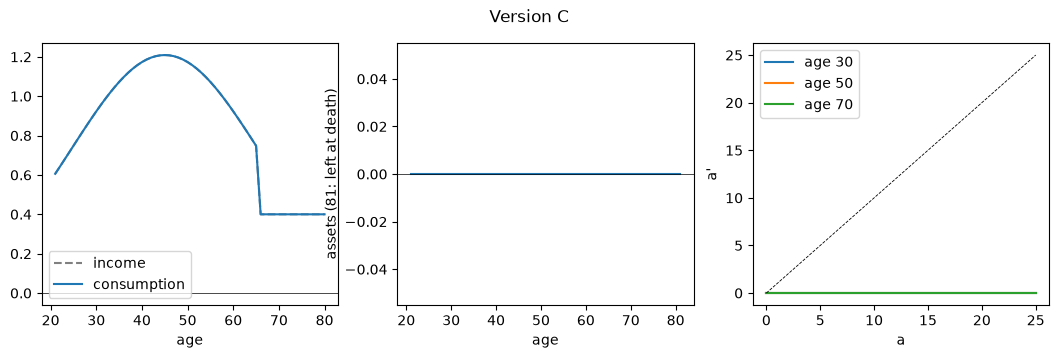

last-age policy saves nothing: True
peak assets 0.00; left at death 0.00; ages with c <= 0: 0
consumption growth, ages 41 to 60: -0.0132


In [7]:
def solve_C(p):
    J, R, beta, sigma = p["J"], p["R"], p["beta"], p["sigma"]
    a = np.linspace(0.0, p["a_max"], p["n_a"])
    y = income_profile(p)
    V = np.zeros((J + 1, len(a)))
    policy = np.zeros((J, len(a)), dtype=int)
    for j in range(J):                             # CHANGED: was range(J - 1, -1, -1)
        c = R * a[:, None] + y[j] - a[None, :]
        u = np.full(c.shape, -np.inf)
        u[c > 0] = utility(c[c > 0], sigma)
        value = u + beta * V[j + 1][None, :]
        policy[j] = value.argmax(axis=1)
        V[j] = value.max(axis=1)
    return dict(a_grid=a, V=V, policy=policy, y=y)

show(solve_C(p), p, "Version C")

### Version D (for pairs who finished early)

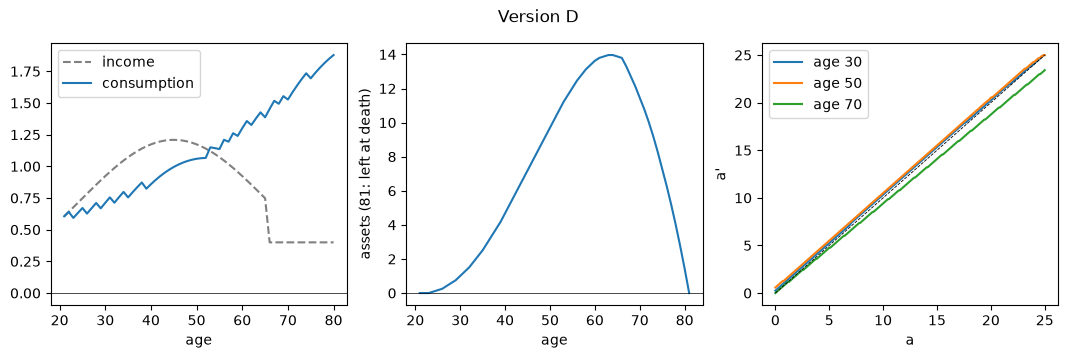

last-age policy saves nothing: True
peak assets 13.96; left at death 0.00; ages with c <= 0: 0
consumption growth, ages 41 to 60: +0.0199


In [8]:
def solve_D(p):
    J, R, beta, sigma = p["J"], p["R"], p["beta"], p["sigma"]
    a = np.linspace(0.0, p["a_max"], p["n_a"])
    y = income_profile(p)
    V = np.zeros((J + 1, len(a)))
    policy = np.zeros((J, len(a)), dtype=int)
    for j in range(J - 1, -1, -1):
        c = R * a[:, None] + y[j] - a[None, :]
        u = np.full(c.shape, -np.inf)
        u[c > 0] = utility(c[c > 0], sigma)
        value = u + V[j + 1][None, :]              # CHANGED: was u + beta * V[j + 1][None, :]
        policy[j] = value.argmax(axis=1)
        V[j] = value.max(axis=1)
    return dict(a_grid=a, V=V, policy=policy, y=y)

show(solve_D(p), p, "Version D")

**A check that passes is not proof.** The last-age check caught A and B and missed C and D. Checks that come from the economics catch more: the two-period closed form called through the solver, the Euler slope, the budget identity.